<a href="https://colab.research.google.com/github/Akira006/noise-aware-federated-learning-dr/blob/main/Notebook/MobileNetV2/exp2_fedavg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2 — Standard Federated Learning (FedAvg)
**Project:** Noise-Aware Federated Learning for Robust Diabetic Retinopathy Classification  
**Model:** MobileNetV2 | **Paradigm:** Standard FedAvg — 3 clients, NO noise augmentation

| Config | Value |
|--------|-------|
| Clients | DDR, EyePACS, APTOS |
| Communication Rounds | 20 (rounds 1-10 frozen, 11-20 unfrozen) |
| Local Epochs / Round | 5 |
| Aggregation | Dataset-size-weighted FedAvg |
| Noise aug (training) | ❌ None |
| Test | Clean + Noisy (seed=123, identik di 3 notebook) |

> ⚠️ **JANGAN ubah `SEED` dan `NOISY_TEST_SEED`** — harus konsisten di 3 notebook.

## 1. GPU Check

In [1]:
!nvidia-smi

Sat May  9 01:01:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Cell 1 — GPU Setup (taruh sebelum semua import)
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"  # lebih stable di G4/L4
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU: {gpus[0].name}")
    print(f"✓ TF version: {tf.__version__}")
else:
    print("No GPU detected")

✓ GPU: /physical_device:GPU:0
✓ TF version: 2.20.0


## 2. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# GPU Memory Growth — prevent CUDA_ERROR_INVALID_HANDLE
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled: {len(gpus)} GPU(s)")

GPU memory growth enabled: 1 GPU(s)


## 3. Imports

In [5]:
import os, json, random, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc, cohen_kappa_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Configuration

In [6]:
# ── REPRODUCIBILITY (sama di 3 notebook) ─────────────────────────
SEED             = 42
NOISY_TEST_SEED  = 123
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── MODEL & EXPERIMENT ────────────────────────────────────────────
MODEL_NAME       = "MobileNetV2"
EXPERIMENT_NAME  = "exp2_fedavg"

# ── TRAINING ──────────────────────────────────────────────────────
IMG_SIZE         = (224, 224)
NUM_CLASSES      = 5
BATCH_SIZE       = 32
LR               = 1e-4
UNFREEZE_N       = 10
DROPOUT          = 0.4
L2               = 1e-4

# ── FL CONFIG ─────────────────────────────────────────────────────
FL_ROUNDS        = 20
LOCAL_EPOCHS     = 5
STAGE1_ROUNDS    = 10   # rounds 1-10: frozen
STAGE2_ROUNDS    = 10   # rounds 11-20: unfrozen

CLIENT_NAMES     = ["DDR","EyePACS","APTOS"]
USE_NOISE_AUG    = False   # Standard FedAvg = no noise

# ── NOISE PARAMS (noisy test set only) ────────────────────────────
NS_MIN, NS_MAX   = 0.01, 0.05
BL_MIN, BL_MAX   = 1.0,  3.0
BR_DELTA         = 0.2
CT_LOW, CT_HIGH  = 0.7,  1.3

CLASS_NAMES  = ["No DR","Mild","Moderate","Severe","Proliferative"]

# ── PATHS ─────────────────────────────────────────────────────────
PROJECT  = "/content/drive/MyDrive/Binus/Semester_4/Research_Methodology"
DS_BASE  = "/content/drive/MyDrive/S-Class/Orion/OrionFL"
BALANCED_DIR = f"{DS_BASE}/balanced"

APTOS_NPZ  = f"{DS_BASE}/balanced/aptos_balanced.npz"
DDR_NPZ    = f"{DS_BASE}/balanced/ddr_balanced.npz"
EYE_NPZ    = f"{DS_BASE}/balanced/eyepacs_balanced.npz"

RES      = f"{PROJECT}/Result/{MODEL_NAME}/{EXPERIMENT_NAME}"
MDL_DIR  = f"{RES}/models"
LOG_DIR  = f"{RES}/logs"
FIG_DIR  = f"{RES}/figures"
for d in [MDL_DIR, LOG_DIR, FIG_DIR]: os.makedirs(d, exist_ok=True)

print(f"Model      : {MODEL_NAME}  |  Use noise aug: {USE_NOISE_AUG}")
print(f"FL rounds  : {FL_ROUNDS} ({STAGE1_ROUNDS} frozen + {STAGE2_ROUNDS} unfrozen)")
print(f"Results    : {RES}")

Model      : MobileNetV2  |  Use noise aug: False
FL rounds  : 20 (10 frozen + 10 unfrozen)
Results    : /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/MobileNetV2/exp2_fedavg


## 5. Load & Split Per Client (70:15:15)

In [7]:
def to01(X):
    X = X.astype(np.float32)
    return X / 255.0 if X.max() > 1.0 else X

def split_dataset(X, y, seed=SEED):
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(X,y,test_size=.30,random_state=seed,stratify=y)
    X_v,X_te,y_v,y_te     = train_test_split(X_tmp,y_tmp,test_size=.50,random_state=seed,stratify=y_tmp)
    return X_tr,X_v,X_te,y_tr,y_v,y_te

print("Loading DDR...")
d = np.load(DDR_NPZ, allow_pickle=True)
X_ddr, y_ddr = to01(d["images"]), d["labels"].astype(np.int64)

print("Loading EyePACS...")
d = np.load(EYE_NPZ, allow_pickle=True)
X_eye = to01(d["images"])
y_eye = d["labels"].astype(np.int64)

print("Loading APTOS...")
d = np.load(APTOS_NPZ, allow_pickle=True)
X_apt, y_apt = to01(d["images"]), d["labels"].astype(np.int64)

Xtr_d,Xv_d,Xte_d,ytr_d,yv_d,yte_d = split_dataset(X_ddr, y_ddr)
Xtr_e,Xv_e,Xte_e,ytr_e,yv_e,yte_e = split_dataset(X_eye, y_eye)
Xtr_a,Xv_a,Xte_a,ytr_a,yv_a,yte_a = split_dataset(X_apt, y_apt)
del X_ddr, X_eye, X_apt; gc.collect()

# Client structures
Xtr = [Xtr_d, Xtr_e, Xtr_a]
ytr = [ytr_d, ytr_e, ytr_a]
csz = [len(ytr_d), len(ytr_e), len(ytr_a)]

X_val   = np.concatenate([Xv_d,  Xv_e,  Xv_a])
y_val   = np.concatenate([yv_d,  yv_e,  yv_a])
X_test  = np.concatenate([Xte_d, Xte_e, Xte_a])
y_test  = np.concatenate([yte_d, yte_e, yte_a])
src_test= np.array(["DDR"]*len(yte_d)+["EyePACS"]*len(yte_e)+["APTOS"]*len(yte_a))

print(f"\nClient sizes: {dict(zip(CLIENT_NAMES, csz))}")
print(f"Total  : {sum(csz):,}")
print(f"Val    : {len(y_val):,}  |  Test: {len(y_test):,}")

Loading DDR...
Loading EyePACS...
Loading APTOS...

Client sizes: {'DDR': 8765, 'EyePACS': 24588, 'APTOS': 2563}
Total  : 35,916
Val    : 7,696  |  Test: 7,698


## 6. Per-Client Class Weights

In [8]:
def get_cw(y):
    cls = np.unique(y)
    cw  = compute_class_weight("balanced", classes=cls, y=y)
    d   = {int(c):float(w) for c,w in zip(cls,cw)}
    for c in range(NUM_CLASSES): d.setdefault(c, 1.0)
    return d

cws = [get_cw(y) for y in ytr]
for name, cw in zip(CLIENT_NAMES, cws):
    print(f"{name}: {cw}")

DDR: {0: 0.3996808025535796, 1: 3.9750566893424035, 2: 0.5593490746649649, 3: 10.624242424242425, 4: 2.7433489827856024}
EyePACS: {0: 0.2721868600210328, 1: 2.8757894736842107, 2: 1.327645788336933, 3: 8.048445171849426, 4: 9.914516129032258}
APTOS: {0: 0.4058590657165479, 1: 1.9791505791505792, 2: 0.7333333333333333, 3: 3.797037037037037, 4: 2.476328502415459}


## 7. Noise Pipeline (Noisy Test Set Only)

In [9]:
def gauss_noise(img,sigma): return np.clip(img+np.random.normal(0,sigma,img.shape).astype(np.float32),0,1)
def gauss_blur(img,sigma): return np.clip(np.stack([gaussian_filter(img[:,:,c],sigma) for c in range(3)],-1).astype(np.float32),0,1)
def bright_contrast(img,bd,cf): m=img.mean(); return np.clip(((img-m)*cf+m+bd).astype(np.float32),0,1)

def degrade(img, rng):
    img = img.copy()
    img = gauss_noise(img,     rng.uniform(NS_MIN,NS_MAX))
    img = gauss_blur(img,      rng.uniform(BL_MIN,BL_MAX))
    img = bright_contrast(img, rng.uniform(-BR_DELTA,BR_DELTA), rng.uniform(CT_LOW,CT_HIGH))
    return img

def make_noisy_set(X, seed=NOISY_TEST_SEED):
    print(f"  Generating noisy set (n={len(X)}, seed={seed})...")
    rng = np.random.default_rng(seed); out = np.empty_like(X)
    for i in range(len(X)): out[i] = degrade(X[i], rng)
    print(f"  Done. range=[{out.min():.3f},{out.max():.3f}]")
    return out

X_test_noisy = make_noisy_set(X_test)

  Generating noisy set (n=7698, seed=123)...
  Done. range=[0.000,1.000]


## 8. Model Builder + FedAvg Aggregation

In [10]:
AUT = tf.data.AUTOTUNE

def make_ds(X, y, shuffle=False, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle: ds = ds.shuffle(len(X), seed=seed)
    return ds.batch(BATCH_SIZE).prefetch(AUT)

def build_model(stage=1):
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(224,224,3))
    base.trainable = False
    if stage == 2:
        base.trainable = True
        for l in base.layers[:-UNFREEZE_N]: l.trainable = False
        for l in base.layers[-UNFREEZE_N:]: l.trainable = True
        for l in base.layers:
            if isinstance(l, layers.BatchNormalization): l.trainable = False
    inp = keras.Input((224,224,3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       kernel_regularizer=regularizers.l2(L2))(x)
    return keras.Model(inp, out)

def fedavg(weights_list, sizes):
    total = sum(sizes)
    agg   = []
    for li in range(len(weights_list[0])):
        agg.append(np.sum([weights_list[i][li]*(sizes[i]/total) for i in range(len(sizes))], axis=0))
    return agg

# Eval datasets (always clean)
val_ds     = make_ds(X_val, y_val)
test_clean = make_ds(X_test, y_test)
test_noisy = make_ds(X_test_noisy, y_test)
print("Eval datasets ready.")

Eval datasets ready.


## 9. Local Training Function

Setiap FL round, tiap client:
1. Load global weights ke fresh model
2. Train E local epochs (clean data — no noise aug)
3. Return updated weights

In [11]:
def local_train(global_w, X, y, cw, stage, seed):
    m = build_model(stage)
    m.set_weights(global_w)
    m.compile(optimizer=keras.optimizers.Adam(LR),
               loss=keras.losses.SparseCategoricalCrossentropy(),
               metrics=["accuracy"])
    ds = make_ds(X, y, shuffle=True, seed=seed)
    h  = m.fit(ds, epochs=LOCAL_EPOCHS, class_weight=cw, verbose=0)
    w, loss, acc = m.get_weights(), h.history["loss"][-1], h.history["accuracy"][-1]
    del m, ds; tf.keras.backend.clear_session(); gc.collect()
    return w, float(loss), float(acc)

print("local_train ready.")

local_train ready.


## 10. FL Training Loop — Synchronous FedAvg

In [12]:
# Init global model
gm = build_model(stage=1)
gm.compile(optimizer=keras.optimizers.Adam(LR),
            loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
gw = gm.get_weights(); del gm; tf.keras.backend.clear_session(); gc.collect()

fl_logs = []
print("="*65)
print(f"  Standard FedAvg | {FL_ROUNDS} rounds × {LOCAL_EPOCHS} local epochs")
print(f"  Stage 1: rounds 1-{STAGE1_ROUNDS} (frozen) | Stage 2: rounds {STAGE1_ROUNDS+1}-{FL_ROUNDS} (unfrozen)")
print("="*65)

for rnd in tqdm(range(1, FL_ROUNDS+1), desc="FL Rounds"):
    t0    = time.time()
    stage = 1 if rnd <= STAGE1_ROUNDS else 2
    print(f"\n[Round {rnd:02d}/{FL_ROUNDS}] Stage {stage}")

    client_ws, client_logs = [], []
    for ci, (cname, cX, cy, cw) in enumerate(zip(CLIENT_NAMES, Xtr, ytr, cws)):
        cw_, loss, acc = local_train(gw, cX, cy, cw, stage, seed=SEED+rnd)
        client_ws.append(cw_)
        client_logs.append({"client":cname,"stage":stage,"loss":loss,"accuracy":acc,"n":int(csz[ci])})
        print(f"  ✓ {cname:<8} loss:{loss:.4f}  acc:{acc:.4f}  n:{csz[ci]:,}")

    # Aggregate
    gw = fedavg(client_ws, csz)

    # Eval global model
    gm = build_model(stage)
    gm.set_weights(gw)
    gm.compile(optimizer=keras.optimizers.Adam(LR),
                loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    vl, va = gm.evaluate(val_ds, verbose=0)
    elapsed = time.time()-t0
    print(f"  ▶ Val loss:{vl:.4f}  acc:{va:.4f}  ({elapsed:.1f}s)")

    fl_logs.append({"round":rnd,"stage":stage,"val_loss":float(vl),"val_accuracy":float(va),
                    "time_sec":round(elapsed,2),"clients":client_logs})

    # Save checkpoint
    gm.save(f"{MDL_DIR}/{EXPERIMENT_NAME}_round{rnd:02d}.keras")
    del client_ws; gc.collect()

print("\n" + "="*65 + "\n  FL TRAINING COMPLETE\n" + "="*65)
gm.save(f"{MDL_DIR}/{EXPERIMENT_NAME}_final.keras")

# Save round logs
pd.DataFrame([{"round":r["round"],"stage":r["stage"],"val_acc":r["val_accuracy"],
               "val_loss":r["val_loss"],"time_sec":r["time_sec"]} for r in fl_logs]
).to_csv(f"{LOG_DIR}/fl_round_summary.csv", index=False)
print(f"Round logs saved: {LOG_DIR}/fl_round_summary.csv")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Standard FedAvg | 20 rounds × 5 local epochs
  Stage 1: rounds 1-10 (frozen) | Stage 2: rounds 11-20 (unfrozen)


FL Rounds:   0%|          | 0/20 [00:00<?, ?it/s]


[Round 01/20] Stage 1
  ✓ DDR      loss:1.3926  acc:0.3771  n:8,765
  ✓ EyePACS  loss:1.4572  acc:0.3224  n:24,588
  ✓ APTOS    loss:1.4133  acc:0.5224  n:2,563
  ▶ Val loss:1.4173  acc:0.4042  (231.3s)

[Round 02/20] Stage 1
  ✓ DDR      loss:1.2512  acc:0.4406  n:8,765
  ✓ EyePACS  loss:1.3905  acc:0.3463  n:24,588
  ✓ APTOS    loss:1.2128  acc:0.5977  n:2,563
  ▶ Val loss:1.3838  acc:0.4057  (150.7s)

[Round 03/20] Stage 1
  ✓ DDR      loss:1.2013  acc:0.4436  n:8,765
  ✓ EyePACS  loss:1.3291  acc:0.3660  n:24,588
  ✓ APTOS    loss:1.1671  acc:0.6219  n:2,563
  ▶ Val loss:1.3416  acc:0.4242  (152.3s)

[Round 04/20] Stage 1
  ✓ DDR      loss:1.1758  acc:0.4564  n:8,765
  ✓ EyePACS  loss:1.3124  acc:0.3732  n:24,588
  ✓ APTOS    loss:1.1179  acc:0.6395  n:2,563
  ▶ Val loss:1.3032  acc:0.4505  (153.0s)

[Round 05/20] Stage 1
  ✓ DDR      loss:1.1578  acc:0.4624  n:8,765
  ✓ EyePACS  loss:1.2932  acc:0.3844  n:24,588
  ✓ APTOS    loss:1.1199  acc:0.6368  n:2,563
  ▶ Val loss:1.3958  a

## 11. FL Training Curves

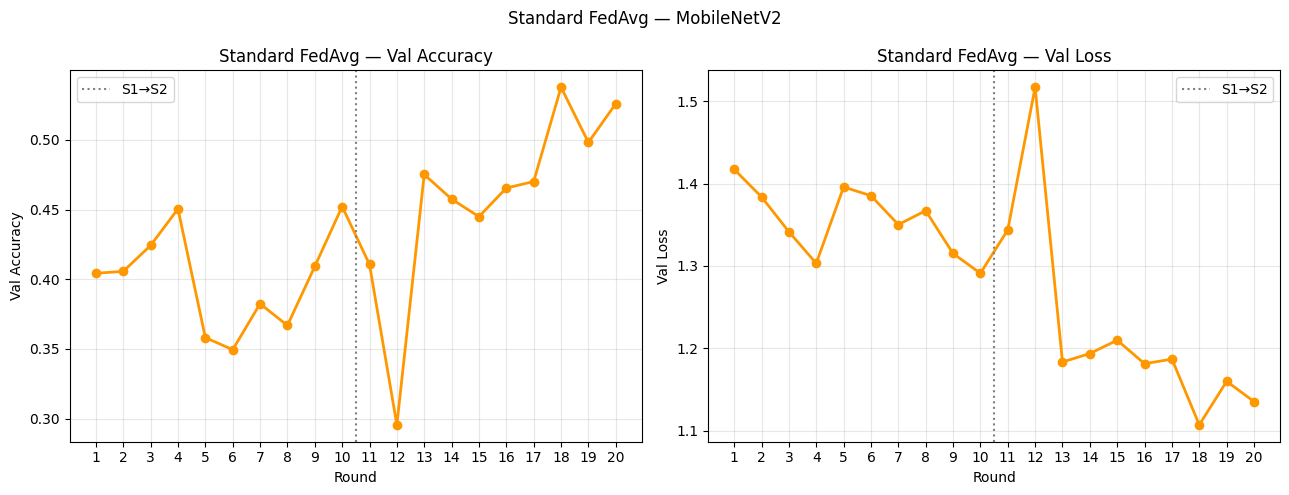

In [13]:
rounds   = [r["round"] for r in fl_logs]
val_acc  = [r["val_accuracy"] for r in fl_logs]
val_loss = [r["val_loss"] for r in fl_logs]
sb       = next((r for r,s in zip(rounds,[r["stage"] for r in fl_logs]) if s==2), None)

fig, ax = plt.subplots(1,2,figsize=(13,5))
for a, data, title in [(ax[0],val_acc,"Val Accuracy"),(ax[1],val_loss,"Val Loss")]:
    a.plot(rounds, data, marker="o", color="#FF9800", lw=2)
    if sb: a.axvline(sb-.5, color="gray", ls=":", lw=1.5, label="S1→S2"); a.legend()
    a.set_xlabel("Round"); a.set_ylabel(title); a.set_title(f"Standard FedAvg — {title}")
    a.grid(alpha=.3); a.set_xticks(rounds)
plt.suptitle(f"Standard FedAvg — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fl_training_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 12. Predict Clean + Noisy

In [14]:
print("Predicting clean...")
yp_clean = gm.predict(test_clean, verbose=1)
yd_clean = np.argmax(yp_clean, 1)

print("Predicting noisy...")
yp_noisy = gm.predict(test_noisy, verbose=1)
yd_noisy = np.argmax(yp_noisy, 1)

Predicting clean...
241/241 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step
Predicting noisy...
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


## 13. Metrics + Robustness Drop

In [15]:
def metrics(yt,yp,yprob):
    a = accuracy_score(yt,yp)
    p,r,f,_ = precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)
    yb = label_binarize(yt,classes=np.arange(NUM_CLASSES))
    try: au = roc_auc_score(yb,yprob,multi_class="ovr",average="macro")
    except: au = float("nan")
    q = cohen_kappa_score(yt,yp,weights="quadratic")
    return dict(accuracy=float(a),precision_macro=float(p),recall_macro=float(r),
                f1_macro=float(f),auc_roc=float(au),qwk=float(q))

MKEYS = ["accuracy","precision_macro","recall_macro","f1_macro","auc_roc","qwk"]
mc = metrics(y_test, yd_clean, yp_clean)
mn = metrics(y_test, yd_noisy, yp_noisy)

print(f"{'Metric':<18} {'Clean':>8} {'Noisy':>8} {'Drop':>8}")
print("-"*44)
rob = {}
for k in MKEYS:
    d = mc[k]-mn[k]; rob[f"drop_{k}"] = float(d)
    print(f"{k:<18} {mc[k]:>8.4f} {mn[k]:>8.4f} {d:>+8.4f}")

Metric                Clean    Noisy     Drop
--------------------------------------------
accuracy             0.5120   0.4192  +0.0928
precision_macro      0.3778   0.2505  +0.1273
recall_macro         0.4048   0.2849  +0.1199
f1_macro             0.3778   0.2150  +0.1629
auc_roc              0.7424   0.5992  +0.1432
qwk                  0.4378   0.1447  +0.2931


## 14. Per-Class Metrics

In [16]:
def per_class(yt,yp):
    p,r,f,s = precision_recall_fscore_support(yt,yp,labels=np.arange(NUM_CLASSES),zero_division=0)
    return pd.DataFrame({"class":np.arange(NUM_CLASSES),"name":CLASS_NAMES,
                          "precision":p,"recall":r,"f1":f,"support":s})
pc_c = per_class(y_test,yd_clean); pc_n = per_class(y_test,yd_noisy)
print("CLEAN:"); print(pc_c.to_string(index=False))
print("\nNOISY:"); print(pc_n.to_string(index=False))
pc_c.to_csv(f"{LOG_DIR}/per_class_clean.csv",index=False)
pc_n.to_csv(f"{LOG_DIR}/per_class_noisy.csv",index=False)

CLEAN:
 class          name  precision   recall       f1  support
     0         No DR   0.787429 0.574267 0.664164     5083
     1          Mild   0.092739 0.249516 0.135220      517
     2      Moderate   0.347009 0.434406 0.385820     1616
     3        Severe   0.211806 0.312821 0.252588      195
     4 Proliferative   0.449827 0.452962 0.451389      287

NOISY:
 class          name  precision   recall       f1  support
     0         No DR   0.734954 0.499705 0.594917     5083
     1          Mild   0.142857 0.007737 0.014679      517
     2      Moderate   0.234091 0.318688 0.269916     1616
     3        Severe   0.054795 0.041026 0.046921      195
     4 Proliferative   0.085653 0.557491 0.148492      287


## 15. Per-Client Breakdown

In [17]:
print(f"{'Client':<10} {'N':>5}  {'Acc_C':>7} {'Acc_N':>7} {'Drop':>7}  {'F1_C':>6} {'F1_N':>6}  {'QWK_C':>7} {'QWK_N':>7}")
print("-"*78)
pcc = {}
for cl in CLIENT_NAMES:
    m = src_test==cl
    if not m.any(): continue
    mc_ = metrics(y_test[m],yd_clean[m],yp_clean[m])
    mn_ = metrics(y_test[m],yd_noisy[m],yp_noisy[m])
    pcc[cl] = {"n":int(m.sum()),"clean":mc_,"noisy":mn_}
    print(f"{cl:<10} {m.sum():>5,}  {mc_['accuracy']:>7.4f} {mn_['accuracy']:>7.4f} {mc_['accuracy']-mn_['accuracy']:>+7.4f}"
          f"  {mc_['f1_macro']:>6.4f} {mn_['f1_macro']:>6.4f}  {mc_['qwk']:>7.4f} {mn_['qwk']:>7.4f}")

Client         N    Acc_C   Acc_N    Drop    F1_C   F1_N    QWK_C   QWK_N
------------------------------------------------------------------------------
DDR        1,879   0.6072  0.3651 +0.2422  0.4068 0.2249   0.5742  0.2200
EyePACS    5,269   0.4703  0.4485 +0.0218  0.3552 0.1941   0.3473  0.0523
APTOS        550   0.5855  0.3236 +0.2618  0.4007 0.2148   0.6168  0.1854


## 16. Confusion Matrices

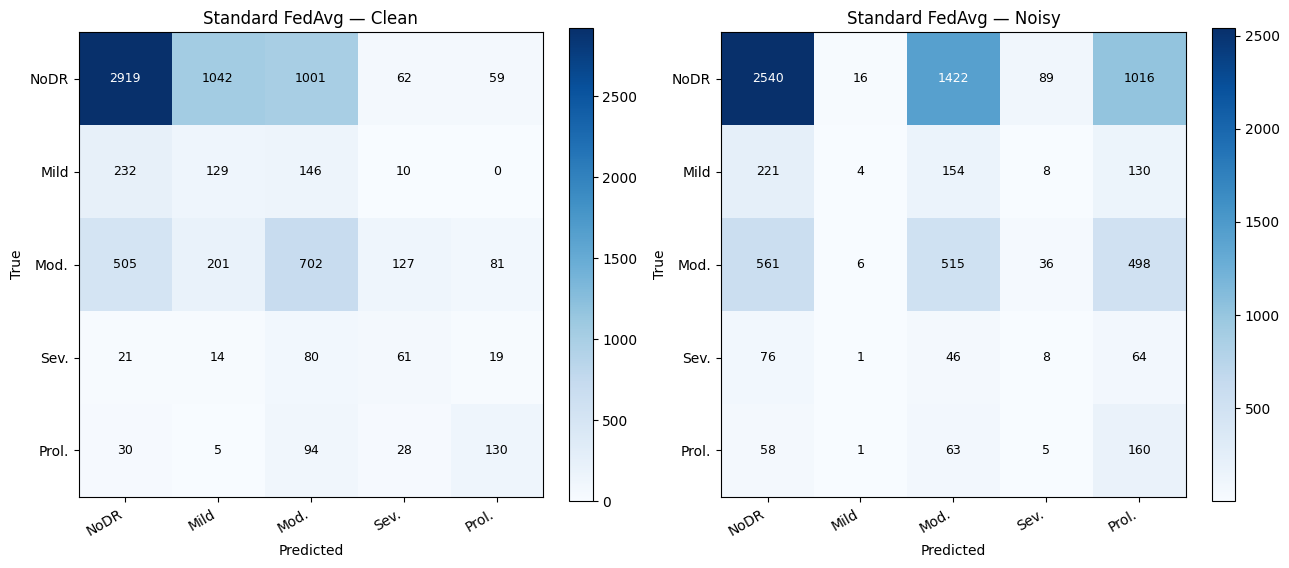

In [18]:
SN = ["NoDR","Mild","Mod.","Sev.","Prol."]
cm_c = confusion_matrix(y_test,yd_clean,labels=np.arange(NUM_CLASSES))
cm_n = confusion_matrix(y_test,yd_noisy,labels=np.arange(NUM_CLASSES))

fig,ax = plt.subplots(1,2,figsize=(13,6))
for a,cm,title in [(ax[0],cm_c,"Clean"),(ax[1],cm_n,"Noisy")]:
    im = a.imshow(cm,cmap="Blues"); plt.colorbar(im,ax=a,fraction=.046)
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(SN,rotation=30,ha="right"); a.set_yticklabels(SN)
    th = cm.max()/2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=9,color="white" if cm[i,j]>th else "black")
    a.set_xlabel("Predicted"); a.set_ylabel("True"); a.set_title(f"Standard FedAvg — {title}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrices.png",dpi=300,bbox_inches="tight"); plt.show()

## 17. ROC Curves

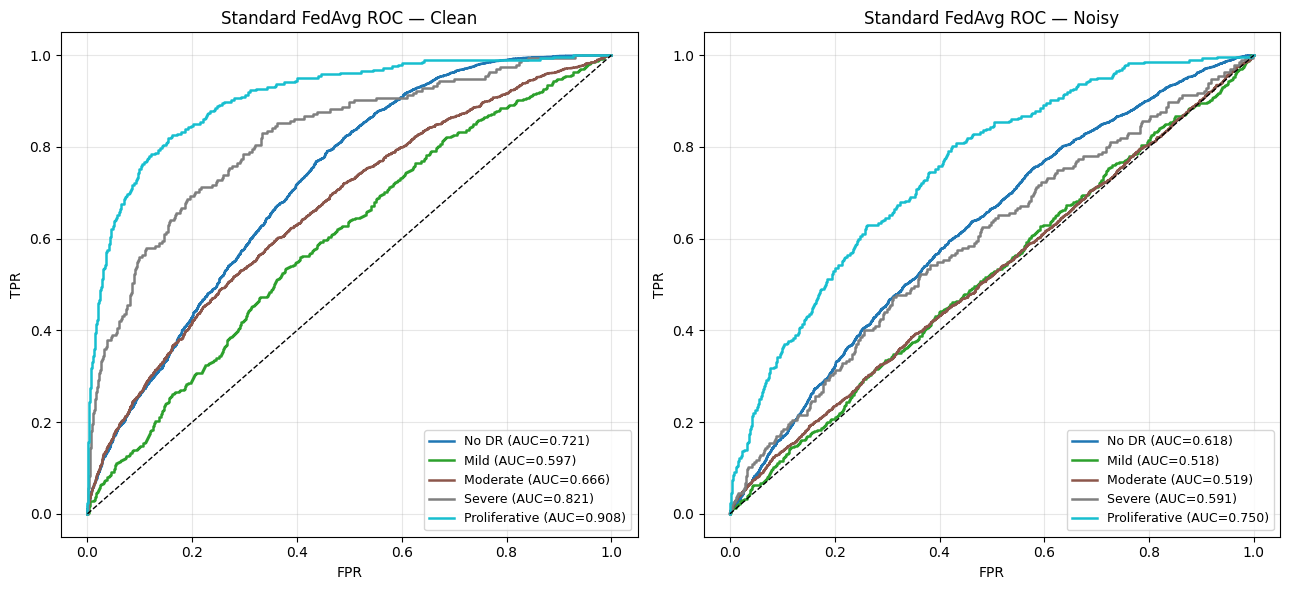

In [19]:
yb   = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
COLS = plt.cm.tab10(np.linspace(0,1,NUM_CLASSES))
fig,ax = plt.subplots(1,2,figsize=(13,6))
for a,yprob,title in [(ax[0],yp_clean,"Clean"),(ax[1],yp_noisy,"Noisy")]:
    for i in range(NUM_CLASSES):
        fpr,tpr,_ = roc_curve(yb[:,i],yprob[:,i])
        a.plot(fpr,tpr,color=COLS[i],lw=1.8,label=f"{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.3f})")
    a.plot([0,1],[0,1],"k--",lw=1); a.set_xlabel("FPR"); a.set_ylabel("TPR")
    a.set_title(f"Standard FedAvg ROC — {title}"); a.legend(fontsize=9,loc="lower right"); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curves.png",dpi=300,bbox_inches="tight"); plt.show()

## 18. Robustness Drop Visualization

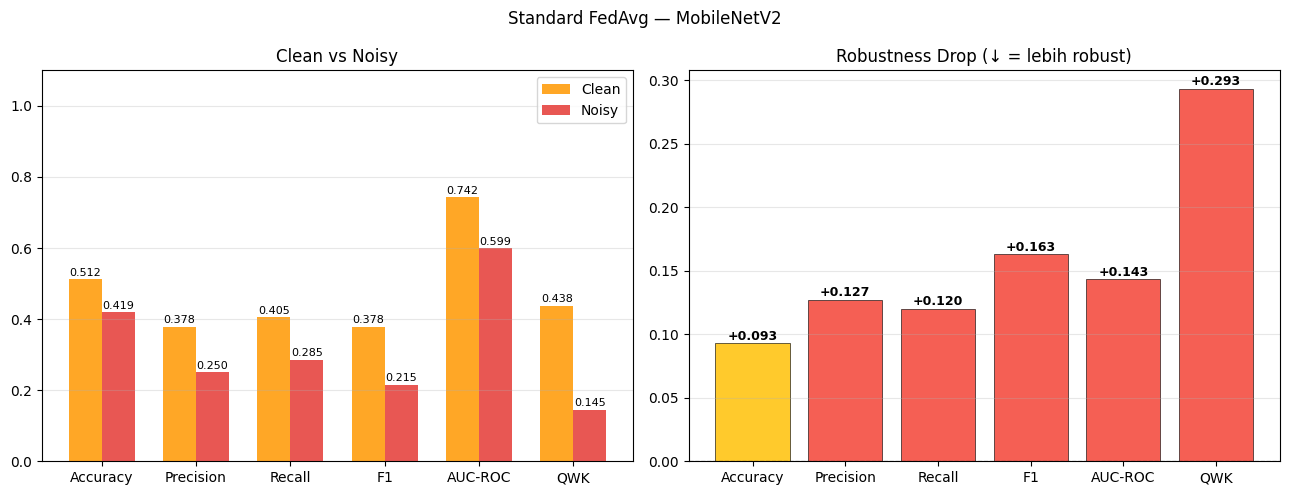

In [20]:
MLABELS = ["Accuracy","Precision","Recall","F1","AUC-ROC","QWK"]
cv=[mc[k] for k in MKEYS]; nv=[mn[k] for k in MKEYS]; dv=[rob[f"drop_{k}"] for k in MKEYS]
x=np.arange(len(MLABELS)); w=.35

fig,ax = plt.subplots(1,2,figsize=(13,5))
ax[0].bar(x-w/2,cv,w,label="Clean",color="#FF9800",alpha=.85)
ax[0].bar(x+w/2,nv,w,label="Noisy",color="#E53935",alpha=.85)
for i,(a_,b_) in enumerate(zip(cv,nv)):
    ax[0].text(i-w/2,a_+.01,f"{a_:.3f}",ha="center",fontsize=8)
    ax[0].text(i+w/2,b_+.01,f"{b_:.3f}",ha="center",fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(MLABELS); ax[0].set_ylim(0,1.1)
ax[0].set_title("Clean vs Noisy"); ax[0].legend(); ax[0].grid(axis="y",alpha=.3)

clrs=["#4CAF50" if d<=.05 else "#FFC107" if d<=.1 else "#F44336" for d in dv]
ax[1].bar(x,dv,color=clrs,alpha=.85,edgecolor="black",lw=.5)
for i,d in enumerate(dv): ax[1].text(i,d+.003,f"{d:+.3f}",ha="center",fontsize=9,fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(MLABELS)
ax[1].set_title("Robustness Drop (↓ = lebih robust)"); ax[1].axhline(0,color="k",lw=.8,ls="--"); ax[1].grid(axis="y",alpha=.3)
plt.suptitle(f"Standard FedAvg — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/robustness_drop.png",dpi=300,bbox_inches="tight"); plt.show()

## 19. Save Results + Summary

In [21]:
res = {
    "experiment":EXPERIMENT_NAME,"model":MODEL_NAME,"paradigm":"Standard FedAvg",
    "use_noise_aug":USE_NOISE_AUG,
    "client_sizes":dict(zip(CLIENT_NAMES,[int(s) for s in csz])),
    "n_test":int(len(y_test)),
    "metrics_clean":mc,"metrics_noisy":mn,"robustness_drop":rob,
    "per_client":pcc,
    "confusion_matrix_clean":cm_c.tolist(),"confusion_matrix_noisy":cm_n.tolist(),
    "config":dict(seed=SEED,noisy_test_seed=NOISY_TEST_SEED,batch=BATCH_SIZE,lr=LR,
                  fl_rounds=FL_ROUNDS,local_epochs=LOCAL_EPOCHS,
                  stage1_rounds=STAGE1_ROUNDS,unfreeze_n=UNFREEZE_N)
}
with open(f"{LOG_DIR}/results.json","w") as f: json.dump(res,f,indent=2)

row={"experiment":EXPERIMENT_NAME,"paradigm":"Standard FedAvg","model":MODEL_NAME}
row.update({f"clean_{k}":mc[k] for k in MKEYS})
row.update({f"noisy_{k}":mn[k] for k in MKEYS})
row.update(rob)
pd.DataFrame([row]).to_csv(f"{LOG_DIR}/summary_row.csv",index=False)
print(f"Saved to: {RES}")

print("\n"+"="*60)
print(f"  EXP2 STANDARD FEDAVG — DONE")
print("="*60)
print(f"  Clients: {CLIENT_NAMES}")
print(f"  CLEAN  | Acc:{mc['accuracy']:.4f}  F1:{mc['f1_macro']:.4f}  AUC:{mc['auc_roc']:.4f}  QWK:{mc['qwk']:.4f}")
print(f"  NOISY  | Acc:{mn['accuracy']:.4f}  F1:{mn['f1_macro']:.4f}  AUC:{mn['auc_roc']:.4f}  QWK:{mn['qwk']:.4f}")
print(f"  DROP   | Acc:{rob['drop_accuracy']:+.4f}  F1:{rob['drop_f1_macro']:+.4f}  AUC:{rob['drop_auc_roc']:+.4f}  QWK:{rob['drop_qwk']:+.4f}")
print("="*60)

Saved to: /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/MobileNetV2/exp2_fedavg

  EXP2 STANDARD FEDAVG — DONE
  Clients: ['DDR', 'EyePACS', 'APTOS']
  CLEAN  | Acc:0.5120  F1:0.3778  AUC:0.7424  QWK:0.4378
  NOISY  | Acc:0.4192  F1:0.2150  AUC:0.5992  QWK:0.1447
  DROP   | Acc:+0.0928  F1:+0.1629  AUC:+0.1432  QWK:+0.2931
